---

In [ ]:
#Name: Anisa
#section: G
#cms-id: 023-24-0222

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [34]:
 import pandas as pd
 import numpy as np
 import matplotlib.pyplot as plt
 from sklearn.model_selection import train_test_split
 from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
 from sklearn.naive_bayes import MultinomialNB
 from sklearn.linear_model import LogisticRegression
 from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [35]:
# Task 1 — load spam.csv, inspect shape/head/class balance

tweets_df = pd.read_csv("Tweets.csv")
spam_df = pd.read_csv("spam.csv", encoding="latin-1")
print(spam_df.shape)
print(spam_df.head)
print(spam_df.columns)

spam_df["v1"].value_counts()




(5572, 5)
<bound method NDFrame.head of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN   

v1
ham     4825
spam     747
Name: count, dtype: int64

In [36]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweet_df = pd.read_csv("Tweets.csv")

tweet_df.shape

tweet_df.head()

tweet_df = tweet_df[tweet_df["airline_sentiment"] != "neutral"]
tweet_df["airline_sentiment"].value_counts()

airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

**Answer 2 (Task A — spam):**
# The first task that is detecting weather a message/email is spam or not spam is practical in our lives as alot of hackers who want to 
# know your credentials try to send spam emails for phishing. If those emails are opened by the user he might be able to get attacked . #Therefore, if our model can easily detect weather a email is spam or not spam will provide help in protecting our devices from attackers.
# This is a binary classification task as it is predicting spam/notspam.
**Answer 2 (Task B — sentiment):**
# The second task in which we are going to basically analyze the sentiments of people regarding company will help us know how people are
# feeling about that company which will help us take better decisions on that.
# This is also binary classification task as we are going to predict positive or negative in this task.


---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [37]:
# Task 3 — clean text
spam_df["v2"] = spam_df["v2"].str.lower()

In [38]:
# Task 4 — encode labels, split, fit vectxxorizer on train only, transform both sets
spam_df["label"] = spam_df["v1"].map({"ham":0, "spam":1})
X = spam_df["v2"]
y = spam_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))



Vocabulary size: 7701


**Answer 4 (why fit on training data only):**
# we fit on training data only to prevent data leakage. The test data or unseen data must not be seen by our model otherwise the data     # will leak and model won't be able to perform well on new data.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.9838565022421525
Precision: 0.9645390070921985
Recall: 0.912751677852349
F1-score: 0.9379310344827586


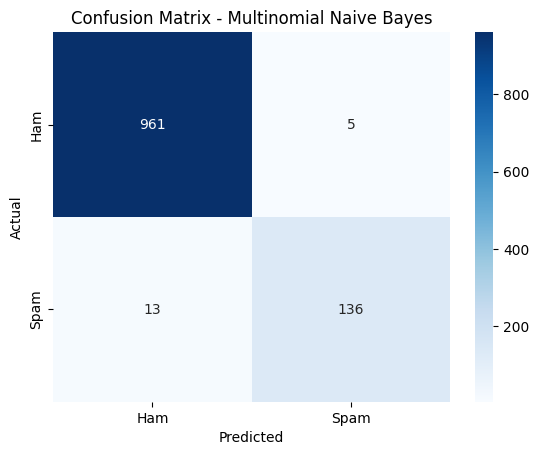

In [39]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred = nb_model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | |
| Precision | |
| Recall | |
| F1-score | |

**Answer 6:**
A false positive can be especially harmful because a legitimate message may be incorrectly marked as spam and hidden from the user. This could cause the user to miss an important message. Therefore, if protecting legitimate messages is the priority, I would prioritize precision, because higher precision means that messages classified as spam are more likely to actually be spam.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [40]:
feature_names = vectorizer.get_feature_names_out()

ham_log_prob = nb_model.feature_log_prob_[0]
spam_log_prob = nb_model.feature_log_prob_[1]

log_prob_diff = spam_log_prob - ham_log_prob

spam_indices = np.argsort(log_prob_diff)[-15:][::-1]

print("Top 15 Spam Words:")
for i in spam_indices:
    print(feature_names[i], log_prob_diff[i])

ham_indices = np.argsort(log_prob_diff)[:15]

print("\nTop 15 Ham Words:")
for i in ham_indices:
    print(feature_names[i], log_prob_diff[i])

Top 15 Spam Words:
claim 5.532028643243501
prize 5.197659456819067
150p 4.985484936875431
tone 4.828299353353018
18 4.715821369926328
cs 4.667031205756896
guaranteed 4.6157379113693455
500 4.6157379113693455
1000 4.504512276259121
uk 4.443887654442686
150ppm 4.3454475816294345
awarded 4.310356261818164
www 4.286258710239104
collection 4.236248289664442
rate 4.197027576511161

Top 15 Ham Words:
gt -4.586368655679734
lt -4.57092433325226
he -4.103252613341503
lor -3.8893826988126223
da -3.8893826988126223
she -3.858130155308518
later -3.7840221831547964
ì_ -3.5436368254060806
ll -3.3348820115439706
doing -3.2985143673730954
say -3.2703434904063995
really -3.2559547529543
ask -3.2559547529543
home -3.24868199362522
anything -3.241355953533147


**Answer 7:**
# yes from the data i can see the words claim prize awarded in the spam category and later, she, ask, home in the ham category which      # clearly suggests that it has predicted right and what I was expecting/

In [41]:
# Task 8 — test your own messages
test_messages = [
    "Congratulations! You have won a free prize. Claim it now!",
    "Hey, are you coming to university tomorrow?",
    "URGENT! You won 50000 rupees. Call now to claim your reward!"
]

test_vectors = vectorizer.transform(test_messages)

predictions = nb_model.predict(test_vectors)

for message, prediction in zip(test_messages, predictions):
    label = "Spam" if prediction == 1 else "Ham"
    print("Message:", message)
    print("Prediction:", label)
    print()

Message: Congratulations! You have won a free prize. Claim it now!
Prediction: Spam

Message: Hey, are you coming to university tomorrow?
Prediction: Ham

Message: URGENT! You won 50000 rupees. Call now to claim your reward!
Prediction: Spam



**Answer 8:**
# yes the predictions matches with what i expected.

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
_(paste your published notebook link here)_

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [42]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
tweets_df['clean_text'] = tweets_df['text'].str.lower()
tweets_df['clean_text'] = tweets_df['clean_text'].str.replace(r'@\w+', '', regex=True)
tweets_df['clean_text'] = tweets_df['clean_text'].str.replace(r'http\S+|www\S+', '', regex=True)

X = tweets_df['clean_text']
y = tweets_df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

**Answer 12:**
# I converted tweets into lowercase and removed links and @ because these just include noise and does not give anything else.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

tweets_df = tweets_df[tweets_df['airline_sentiment'].isin(['positive', 'negative'])]

X_train, X_test, y_train, y_test = train_test_split(
    tweets_df['text'], tweets_df['airline_sentiment'],
    test_size=0.2, random_state=42, stratify=tweets_df['airline_sentiment']
)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(y_test.unique())  # sirf ['negative' 'positive'] aana chahiye

['negative' 'positive']


Accuracy: 0.9055868341273279
Precision: 0.8947368421052632
Recall: 0.6109936575052854
F1-score: 0.7261306532663316


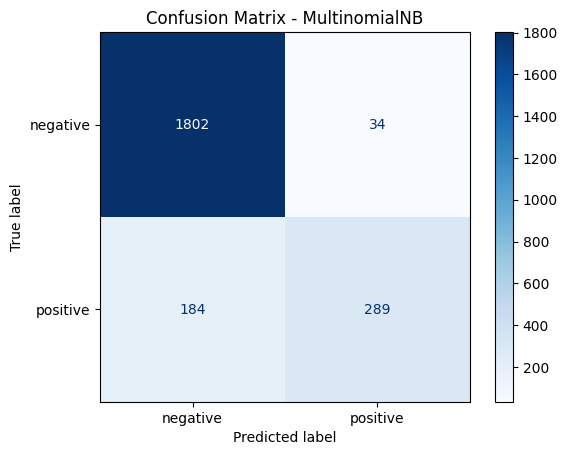

In [55]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='positive')
recall = recall_score(y_test, y_pred, pos_label='positive')
f1 = f1_score(y_test, y_pred, pos_label='positive')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix - MultinomialNB")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.9055868341273279 |
| Precision |0.8947368421052632 |
| Recall |0.6109936575052854 |
| F1-score |0.7261306532663316 |

Answer 14:
# Naive Bayes performed worse on sentiment classification than on spam classification. For sentiment, it achieved 90.56% accuracy and an   F1-score of 72.61%, while for spam it achieved 98.39% accuracy and an F1-score of 93.79%. The independence assumption works better for spam because spam messages often use simple and repeated words. For tweets, it is less suitable because words can depend on each other, especially with sarcasm, negation like “not good,” and the overall context.


---

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

In [56]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Task A - Spam': [0.9839, 0.9645, 0.9128, 0.9379],
    'Task B - Sentiment': [0.9056, 0.8947, 0.6110, 0.7261]
})

comparison

,Metric,Task A - Spam,Task B - Sentiment
0,Accuracy,0.9839,0.9056
1,Precision,0.9645,0.8947
2,Recall,0.9128,0.6110
3,F1-score,0.9379,0.7261


**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | | |
| Precision | | |
| Recall | | |
| F1-score | | |

In [59]:

data = pd.read_csv('spam.csv', encoding='latin-1')

data = data[['v1', 'v2']]
data.columns = ['label', 'text']

data['label'] = data['label'].map({'ham': 0, 'spam': 1})

X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

comparison_lr = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Naive Bayes': [
        accuracy_score(y_test, nb_pred),
        precision_score(y_test, nb_pred),
        recall_score(y_test, nb_pred),
        f1_score(y_test, nb_pred)
    ],
    'Logistic Regression': [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred)
    ]
})

comparison_lr

,Metric,Naive Bayes,Logistic Regression
0,Accuracy,0.960538,0.972197
1,Precision,1.000000,0.991667
2,Recall,0.704698,0.798658
3,F1-score,0.826772,0.884758


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted